In [ ]:
#Cone beam ct artifact removal using deep learning
#The data is from the paper "Deep learning for cone-beam computed tomography artifact removal in dental and maxillofacial imaging" 
# by H. Chen et al., published in 2020 in the journal "Medical Physics". The data is available on the website of the authors at
#link: https://zenodo.org/records/2686726

# Step 1 — Initial Proof-of-Concept: U-Net for CBCT Artifact Reduction

### Dataset Overview

The Walnut CBCT dataset contains reconstructed volumes generated from **three different source-detector orbit positions**. For each walnut, single-orbit **FDK reconstructions** are available as `fdk_pos1`, `fdk_pos2`, and `fdk_pos3`.

These three positions represent different acquisition orbits rather than X/Y/Z spatial directions. A high-quality `full_AGD_50` reconstruction, generated using information from all three orbits, is used as the **reference target** for the deep learning model.

In this first experiment, `fdk_pos1` is used as the input and `full_AGD_50` as the target for training the U-Net to reduce high cone-angle artifacts.

In [ ]:
# get the current working directory
import os
os.getcwd()

'/content/drive/MyDrive/WalnutsOwnReconstructions/walnut1'

In [ ]:
# used colab to run the notebook, so we need to mount the drive to access the data
from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# be sure that the drive is mounted, and if it is already mounted, force remount it
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# check the contents of the mounted drive
%ls

walnut1/  walnut2/  walnut3/


In [ ]:
# get into the walnut1 directory and check the contents
%cd /content/drive/MyDrive/WalnutsOwnReconstructions/walnut1
%ls 

/content/drive/MyDrive/WalnutsOwnReconstructions/walnut1
best_unet_pos1.pth    fdk_pos2_000167.tiff  fdk_pos3_000335.tiff
fdk_pos1_000000.tiff  fdk_pos2_000168.tiff  fdk_pos3_000336.tiff
fdk_pos1_000001.tiff  fdk_pos2_000169.tiff  fdk_pos3_000337.tiff
fdk_pos1_000002.tiff  fdk_pos2_000170.tiff  fdk_pos3_000338.tiff
fdk_pos1_000003.tiff  fdk_pos2_000171.tiff  fdk_pos3_000339.tiff
fdk_pos1_000004.tiff  fdk_pos2_000172.tiff  fdk_pos3_000340.tiff
fdk_pos1_000005.tiff  fdk_pos2_000173.tiff  fdk_pos3_000341.tiff
fdk_pos1_000006.tiff  fdk_pos2_000174.tiff  fdk_pos3_000342.tiff
fdk_pos1_000007.tiff  fdk_pos2_000175.tiff  fdk_pos3_000343.tiff
fdk_pos1_000008.tiff  fdk_pos2_000176.tiff  fdk_pos3_000344.tiff
fdk_pos1_000009.tiff  fdk_pos2_000177.tiff  fdk_pos3_000345.tiff
fdk_pos1_000010.tiff  fdk_pos2_000178.tiff  fdk_pos3_000346.tiff
fdk_pos1_000011.tiff  fdk_pos2_000179.tiff  fdk_pos3_000347.tiff
fdk_pos1_000012.tiff  fdk_pos2_000180.tiff  fdk_pos3_000348.tiff
fdk_pos1_000013.tiff  fdk_pos2_00

In [15]:
# The files in the current directory are: well uploaded and ready for processing.

In [ ]:
# let's check the current working directory
from pathlib import Path

root = Path("/content/drive/MyDrive/WalnutsOwnReconstructions/walnut1")

files = sorted(root.glob("*.tiff"))

print("Number of TIFF files:", len(files))

for f in files[:30]:
    print(f.name)

Number of TIFF files: 2004
fdk_pos1_000000.tiff
fdk_pos1_000001.tiff
fdk_pos1_000002.tiff
fdk_pos1_000003.tiff
fdk_pos1_000004.tiff
fdk_pos1_000005.tiff
fdk_pos1_000006.tiff
fdk_pos1_000007.tiff
fdk_pos1_000008.tiff
fdk_pos1_000009.tiff
fdk_pos1_000010.tiff
fdk_pos1_000011.tiff
fdk_pos1_000012.tiff
fdk_pos1_000013.tiff
fdk_pos1_000014.tiff
fdk_pos1_000015.tiff
fdk_pos1_000016.tiff
fdk_pos1_000017.tiff
fdk_pos1_000018.tiff
fdk_pos1_000019.tiff
fdk_pos1_000020.tiff
fdk_pos1_000021.tiff
fdk_pos1_000022.tiff
fdk_pos1_000023.tiff
fdk_pos1_000024.tiff
fdk_pos1_000025.tiff
fdk_pos1_000026.tiff
fdk_pos1_000027.tiff
fdk_pos1_000028.tiff
fdk_pos1_000029.tiff


In [ ]:
# lets sort the files by name and print the first 30 files
files = sorted(root.glob("*.tiff"))

for f in files:
    print(f.name)

fdk_pos1_000000.tiff
fdk_pos1_000001.tiff
fdk_pos1_000002.tiff
fdk_pos1_000003.tiff
fdk_pos1_000004.tiff
fdk_pos1_000005.tiff
fdk_pos1_000006.tiff
fdk_pos1_000007.tiff
fdk_pos1_000008.tiff
fdk_pos1_000009.tiff
fdk_pos1_000010.tiff
fdk_pos1_000011.tiff
fdk_pos1_000012.tiff
fdk_pos1_000013.tiff
fdk_pos1_000014.tiff
fdk_pos1_000015.tiff
fdk_pos1_000016.tiff
fdk_pos1_000017.tiff
fdk_pos1_000018.tiff
fdk_pos1_000019.tiff
fdk_pos1_000020.tiff
fdk_pos1_000021.tiff
fdk_pos1_000022.tiff
fdk_pos1_000023.tiff
fdk_pos1_000024.tiff
fdk_pos1_000025.tiff
fdk_pos1_000026.tiff
fdk_pos1_000027.tiff
fdk_pos1_000028.tiff
fdk_pos1_000029.tiff
fdk_pos1_000030.tiff
fdk_pos1_000031.tiff
fdk_pos1_000032.tiff
fdk_pos1_000033.tiff
fdk_pos1_000034.tiff
fdk_pos1_000035.tiff
fdk_pos1_000036.tiff
fdk_pos1_000037.tiff
fdk_pos1_000038.tiff
fdk_pos1_000039.tiff
fdk_pos1_000040.tiff
fdk_pos1_000041.tiff
fdk_pos1_000042.tiff
fdk_pos1_000043.tiff
fdk_pos1_000044.tiff
fdk_pos1_000045.tiff
fdk_pos1_000046.tiff
fdk_pos1_0000

In [ ]:
# let's check the number of files in the directory and their prefixes
from pathlib import Path
from collections import Counter

root = Path("/content/drive/MyDrive/WalnutsOwnReconstructions/walnut1")

files = sorted(root.glob("*.tiff"))

print("Total TIFF files:", len(files))

# Look at filename prefixes
prefixes = Counter()

for f in files:
    name = f.stem

    if name.startswith("fdk_pos1"):
        prefixes["fdk_pos1"] += 1
    elif name.startswith("fdk_pos2"):
        prefixes["fdk_pos2"] += 1
    elif name.startswith("fdk_pos3"):
        prefixes["fdk_pos3"] += 1
    elif name.startswith("full_AGD"):
        prefixes["full_AGD"] += 1
    elif name.startswith("nnls"):
        prefixes["nnls"] += 1
    else:
        prefixes["other"] += 1

print(prefixes)

Total TIFF files: 2004
Counter({'fdk_pos1': 501, 'fdk_pos2': 501, 'fdk_pos3': 501, 'full_AGD': 501})


In [ ]:
# let's read one of the TIFF files and check its properties
import tifffile
import numpy as np

img = tifffile.imread(files[0])

print("Shape:", img.shape)
print("Data type:", img.dtype)
print("Minimum:", img.min())
print("Maximum:", img.max())
print("Mean:", img.mean())
print("Standard deviation:", img.std())

Shape: (501, 501)
Data type: float32
Minimum: -0.0015896376
Maximum: 0.010553518
Mean: 0.0023127673
Standard deviation: 0.0011771647


FDK shape: (501, 501)
GT shape: (501, 501)
FDK dtype: float32
GT dtype: float32
FDK range: -0.010352221 to 0.068965636
GT range: 0.0 to 0.06809039


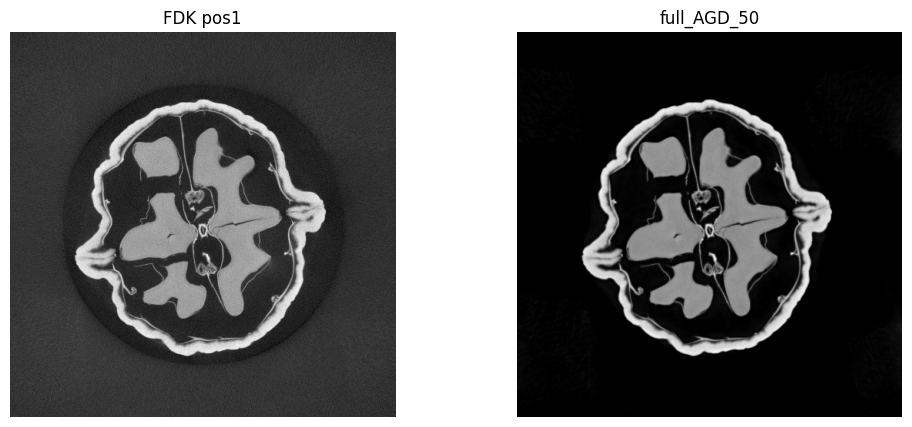

In [ ]:
# let's read two specific TIFF files and compare them
from pathlib import Path
import tifffile
import matplotlib.pyplot as plt

root = Path("/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions")

fdk_file = root / "fdk_pos1_000250.tiff"
gt_file = root / "full_AGD_50_000250.tiff"

fdk = tifffile.imread(fdk_file)
gt = tifffile.imread(gt_file)

print("FDK shape:", fdk.shape)
print("GT shape:", gt.shape)

print("FDK dtype:", fdk.dtype)
print("GT dtype:", gt.dtype)

print("FDK range:", fdk.min(), "to", fdk.max())
print("GT range:", gt.min(), "to", gt.max())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(fdk, cmap="gray")
plt.title("FDK pos1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gt, cmap="gray")
plt.title("full_AGD_50")
plt.axis("off")

plt.show()

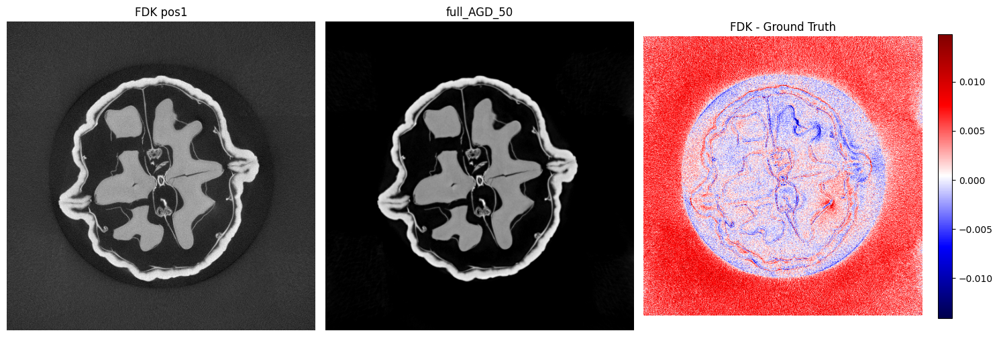

Difference mean: 0.003234392
Difference std: 0.0034496887
Difference min: -0.014075374
Difference max: 0.014873927


In [ ]:
# let's compute the difference between the two images and visualize it
import numpy as np
import matplotlib.pyplot as plt

difference = fdk - gt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(fdk, cmap="gray")
axes[0].set_title("FDK pos1")
axes[0].axis("off")

axes[1].imshow(gt, cmap="gray")
axes[1].set_title("full_AGD_50")
axes[1].axis("off")

im = axes[2].imshow(difference, cmap="seismic")
axes[2].set_title("FDK - Ground Truth")
axes[2].axis("off")

plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

print("Difference mean:", difference.mean())
print("Difference std:", difference.std())
print("Difference min:", difference.min())
print("Difference max:", difference.max())

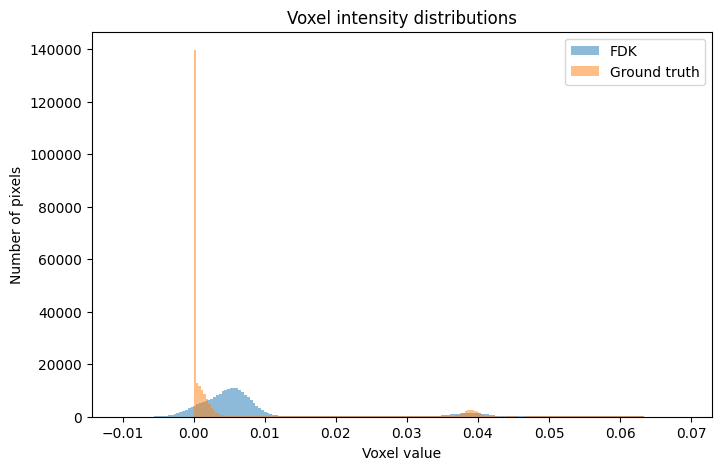

In [ ]:
# let's visualize the histogram of the voxel values for both images
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(fdk.ravel(), bins=200, alpha=0.5, label="FDK")
plt.hist(gt.ravel(), bins=200, alpha=0.5, label="Ground truth")

plt.xlabel("Voxel value")
plt.ylabel("Number of pixels")
plt.title("Voxel intensity distributions")
plt.legend()
plt.show()

In [ ]:
#let's compute the mean and standard deviation of the voxel values for both images
print("FDK mean/std:", fdk.mean(), fdk.std())
print("GT mean/std:", gt.mean(), gt.std())

FDK mean/std: 0.010518744 0.014574307
GT mean/std: 0.0072843516 0.015599047


In [ ]:
#lets define a PyTorch dataset class to load the images and their corresponding ground truth images
from pathlib import Path
import numpy as np
import tifffile
import torch
from torch.utils.data import Dataset

class WalnutDataset(Dataset):
    def __init__(self, root, position="pos1"):
        self.root = Path(root)

        self.inputs = sorted(
            self.root.glob(f"fdk_{position}_*.tiff")
        )

        self.targets = sorted(
            self.root.glob("full_AGD_50_*.tiff")
        )

        assert len(self.inputs) == len(self.targets), \
            f"Mismatch: {len(self.inputs)} inputs, {len(self.targets)} targets"

        print(f"Found {len(self.inputs)} image pairs")

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):

        x = tifffile.imread(self.inputs[idx]).astype(np.float32)
        y = tifffile.imread(self.targets[idx]).astype(np.float32)

        # Add channel dimension: (501, 501) -> (1, 501, 501)
        x = torch.from_numpy(x).unsqueeze(0)
        y = torch.from_numpy(y).unsqueeze(0)

        return x, y

In [ ]:
# let's check the number of files in the directory and their prefixes
# the folder name: Reconstructions is changed to walnut1, so we need to update the path accordingly
from pathlib import Path

tiff_files = list(Path("/content/drive/MyDrive/WalnutsOwnReconstructions/walnut1").rglob("fdk_pos1_*.tiff"))

print("Found:", len(tiff_files))

for f in tiff_files[:10]:
    print(f)

Found: 501
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000088.tiff
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000282.tiff
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000390.tiff
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000378.tiff
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000435.tiff
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000007.tiff
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000021.tiff
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000005.tiff
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000289.tiff
/content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions/fdk_pos1_000099.tiff


In [ ]:
# let's check the number of files in the directory and their prefixes again
from pathlib import Path

root = Path("/content/drive/MyDrive/WalnutsOwnReconstructions/walnut1")

print("FDK pos1:", len(list(root.glob("fdk_pos1_*.tiff"))))
print("FDK pos2:", len(list(root.glob("fdk_pos2_*.tiff"))))
print("FDK pos3:", len(list(root.glob("fdk_pos3_*.tiff"))))
print("Ground truth:", len(list(root.glob("full_AGD_50_*.tiff"))))

FDK pos1: 501
FDK pos2: 501
FDK pos3: 501
Ground truth: 501


In [ ]:
# let's create a dataset instance and check its length
dataset = WalnutDataset(root, position="pos1")

print("Dataset length:", len(dataset))

Found 501 image pairs
Dataset length: 501


In [ ]:
# let's check the shape and data type of the input and target images for a specific index
x, y = dataset[250]

print("Input shape:", x.shape)
print("Target shape:", y.shape)
print("Input dtype:", x.dtype)
print("Target dtype:", y.dtype)

Input shape: torch.Size([1, 501, 501])
Target shape: torch.Size([1, 501, 501])
Input dtype: torch.float32
Target dtype: torch.float32


In [ ]:
# Let's do this cleanly and check if the folder exists
from pathlib import Path

root = Path("/content/drive/MyDrive/WalnutsOwnReconstructions/walnut1")

print("Folder exists:", root.exists())

Folder exists: True


In [ ]:
# let's check the number of input and target files in the dataset
inputs = sorted(root.glob("fdk_pos1_*.tiff"))
targets = sorted(root.glob("full_AGD_50_*.tiff"))

print("Input files:", len(inputs))
print("Target files:", len(targets))

print("\nFirst 3 inputs:")
for f in inputs[:3]:
    print(f.name)

print("\nLast 3 inputs:")
for f in inputs[-3:]:
    print(f.name)

Input files: 501
Target files: 501

First 3 inputs:
fdk_pos1_000000.tiff
fdk_pos1_000001.tiff
fdk_pos1_000002.tiff

Last 3 inputs:
fdk_pos1_000498.tiff
fdk_pos1_000499.tiff
fdk_pos1_000500.tiff


In [ ]:
# let's check the first and last target files
import numpy as np
import tifffile
import torch
from torch.utils.data import Dataset


class WalnutDataset(Dataset):

    def __init__(self, root, position="pos1"):

        self.root = Path(root)

        self.inputs = sorted(
            self.root.glob(f"fdk_{position}_*.tiff")
        )

        self.targets = sorted(
            self.root.glob("full_AGD_50_*.tiff")
        )

        if len(self.inputs) == 0:
            raise RuntimeError(
                f"No FDK files found in: {self.root}"
            )

        if len(self.targets) == 0:
            raise RuntimeError(
                f"No ground-truth files found in: {self.root}"
            )

        if len(self.inputs) != len(self.targets):
            raise RuntimeError(
                f"Mismatch: {len(self.inputs)} inputs "
                f"but {len(self.targets)} targets"
            )

        print(f"Found {len(self.inputs)} input images")
        print(f"Found {len(self.targets)} target images")

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):

        x = tifffile.imread(self.inputs[idx]).astype(np.float32)
        y = tifffile.imread(self.targets[idx]).astype(np.float32)

        # Add channel dimension
        x = torch.from_numpy(x).unsqueeze(0)
        y = torch.from_numpy(y).unsqueeze(0)

        return x, y

In [ ]:
#§ let's check the number of input and target files in the dataset
dataset = WalnutDataset(root, position="pos1")

print("Dataset length:", len(dataset))

Found 501 input images
Found 501 target images
Dataset length: 501


In [ ]:
# let's check the shape and data type of the input and target images for a specific index
x, y = dataset[250]

print("Input shape:", x.shape)
print("Target shape:", y.shape)
print("Input dtype:", x.dtype)
print("Target dtype:", y.dtype)

Input shape: torch.Size([1, 501, 501])
Target shape: torch.Size([1, 501, 501])
Input dtype: torch.float32
Target dtype: torch.float32


In [40]:
#For this first Walnut experiment, we'll split the 501 slices sequentially:

#70% training
#15% validation
#15% test

In [ ]:
# let's split the dataset into training, validation, and test sets
from torch.utils.data import random_split

train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Training: 350
Validation: 75
Test: 76


In [ ]:
# let's create DataLoaders for the training, validation, and test sets
from torch.utils.data import DataLoader

batch_size = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
# let's check the shape of a batch from the training DataLoader
x_batch, y_batch = next(iter(train_loader))

print("Input batch:", x_batch.shape)
print("Target batch:", y_batch.shape)

Input batch: torch.Size([4, 1, 501, 501])
Target batch: torch.Size([4, 1, 501, 501])


In [ ]:
# Let's see if the GPU can run the U-Net model. If it can, we will use it for training.
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output
        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        # Bottleneck
        b = self.bottleneck(self.pool3(e3))

        # Decoder
        d3 = self.up3(b)

        # Make decoder size match skip connection
        d3 = F.interpolate(
            d3,
            size=e3.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = F.interpolate(
            d2,
            size=e2.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = F.interpolate(
            d1,
            size=e1.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [ ]:
# let's check if the GPU can run the U-Net model. If it can, we will use it for training.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

model = UNet().to(device)

x_batch, y_batch = next(iter(train_loader))

x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    prediction = model(x_batch)

print("Input:     ", x_batch.shape)
print("Prediction:", prediction.shape)
print("Target:    ", y_batch.shape)

Device: cuda
Input:      torch.Size([4, 1, 501, 501])
Prediction: torch.Size([4, 1, 501, 501])
Target:     torch.Size([4, 1, 501, 501])


In [ ]:
# let's define a function to calculate the RMSE between two tensors
import torch
import numpy as np


def calculate_rmse(x, y):
    return torch.sqrt(torch.mean((x - y) ** 2)).item()


model.eval()

baseline_rmse = 0.0
num_batches = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        rmse = calculate_rmse(x, y)

        baseline_rmse += rmse
        num_batches += 1

baseline_rmse /= num_batches

print(f"Baseline FDK RMSE: {baseline_rmse:.6f}")

Baseline FDK RMSE: 0.003855


In [ ]:
# let's define the loss function and optimizer for training the U-Net model
import torch.nn as nn

criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: L1Loss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [ ]:
# let's train the U-Net model for one epoch and print the training loss
model.train()

x_batch, y_batch = next(iter(train_loader))

x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

optimizer.zero_grad()

prediction = model(x_batch)

loss = criterion(prediction, y_batch)

loss.backward()

optimizer.step()

print(f"Training loss: {loss.item():.6f}")

Training loss: 0.113036


In [51]:
# Recreate the model and optimizer for training from scratch
model = UNet().to(device)

criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
# let's train the U-Net model for multiple epochs and save the best model based on validation loss
num_epochs = 10

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        prediction = model(x)

        loss = criterion(prediction, y)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            prediction = model(x)

            loss = criterion(prediction, y)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_unet_pos1.pth"
        )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch [1/10] Train Loss: 0.005530 Val Loss: 0.004758
Epoch [2/10] Train Loss: 0.004571 Val Loss: 0.004364
Epoch [3/10] Train Loss: 0.003707 Val Loss: 0.003472
Epoch [4/10] Train Loss: 0.001843 Val Loss: 0.001697
Epoch [5/10] Train Loss: 0.001359 Val Loss: 0.001353
Epoch [6/10] Train Loss: 0.001309 Val Loss: 0.001274
Epoch [7/10] Train Loss: 0.001348 Val Loss: 0.001290
Epoch [8/10] Train Loss: 0.001263 Val Loss: 0.001238
Epoch [9/10] Train Loss: 0.001221 Val Loss: 0.001237
Epoch [10/10] Train Loss: 0.001246 Val Loss: 0.001349


In [53]:
# Load the best model
model.load_state_dict(
    torch.load("best_unet_pos1.pth", map_location=device)
)

model.eval()

total_squared_error = 0.0
total_pixels = 0

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        prediction = model(x)

        squared_error = (prediction - y) ** 2

        total_squared_error += squared_error.sum().item()
        total_pixels += squared_error.numel()

test_rmse = (total_squared_error / total_pixels) ** 0.5

print(f"FDK baseline RMSE: {baseline_rmse:.6f}")
print(f"U-Net test RMSE:   {test_rmse:.6f}")

FDK baseline RMSE: 0.003855
U-Net test RMSE:   0.003042


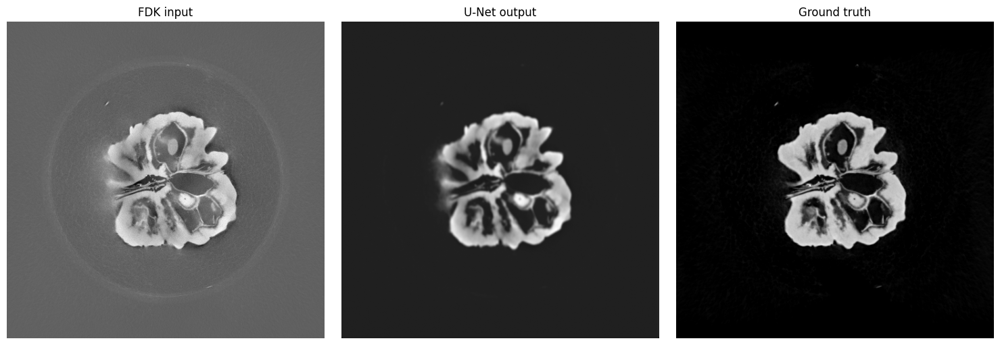

In [ ]:
# let's visualize the input, output, and ground truth for a specific test sample
import matplotlib.pyplot as plt

model.eval()

x, y = test_dataset[10]

with torch.no_grad():
    prediction = model(
        x.unsqueeze(0).to(device)
    ).cpu().squeeze(0).squeeze(0)

x = x.squeeze(0)
y = y.squeeze(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(x.numpy(), cmap="gray")
axes[0].set_title("FDK input")
axes[0].axis("off")

axes[1].imshow(prediction.numpy(), cmap="gray")
axes[1].set_title("U-Net output")
axes[1].axis("off")

axes[2].imshow(y.numpy(), cmap="gray")
axes[2].set_title("Ground truth")
axes[2].axis("off")

plt.tight_layout()
plt.show()

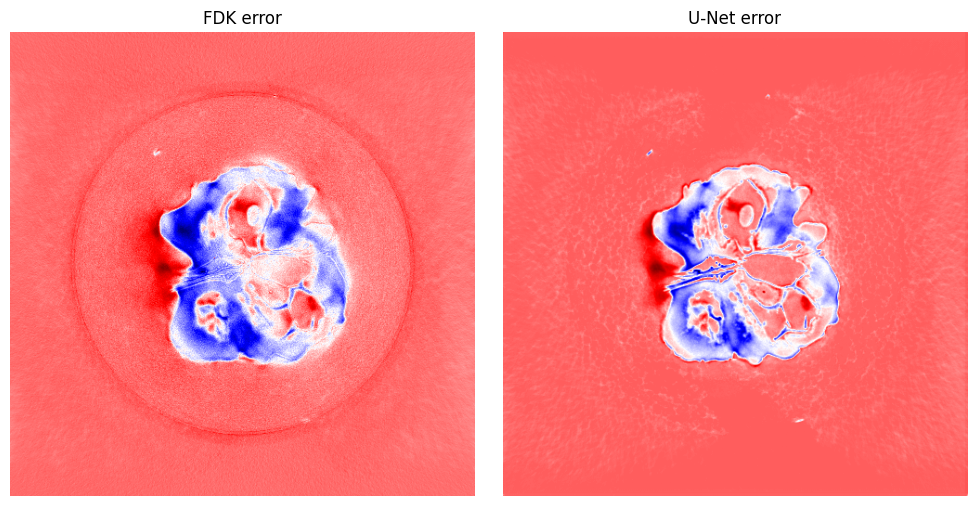

In [ ]:
# let's visualize the error maps for the FDK input and U-Net output compared to the ground truth
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

fdk_error = (x.numpy() - y.numpy())
unet_error = (prediction.numpy() - y.numpy())

axes[0].imshow(fdk_error, cmap="seismic")
axes[0].set_title("FDK error")
axes[0].axis("off")

axes[1].imshow(unet_error, cmap="seismic")
axes[1].set_title("U-Net error")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Initial U-Net Experiment — Walnut1 / Position 1

A first proof-of-concept U-Net was trained using `fdk_pos1` reconstructions from **Walnut1** as input and `full_AGD_50` as the target reference.

The model was trained for **10 epochs** using **L1 loss** and the Adam optimizer with a learning rate of **1×10⁻⁴**.

On the test data, the single-orbit FDK reconstruction achieved an RMSE of **0.003855**, while the U-Net reduced the RMSE to **0.003042**, corresponding to an approximately **21.1% reduction in RMSE**.

This initial experiment demonstrated that a U-Net can learn to reduce high cone-angle reconstruction errors and provided the basis for the subsequent **multi-walnut training experiment**.


# Step 2 — Multi-Walnut Training: U-Net for CBCT Artifact Reduction

In this experiment, the U-Net was trained on multiple walnut samples to improve its ability to generalize across different objects.

The model uses **single-orbit `fdk_pos1` reconstructions as input** and the high-quality **`full_AGD_50` reconstruction as the reference target**.

- **Training:** Walnut1, Walnut2, Walnut3
- **Validation:** Walnut4
- **Testing:** Walnut5 (unseen during training)
- **Input:** `fdk_pos1`
- **Target:** `full_AGD_50`
- **Loss:** L1 Loss
- **Optimizer:** Adam
- **Learning rate:** `1e-4`
- **Training:** 20 epochs

This experiment evaluates whether the U-Net can learn to reduce high cone-angle artifacts from `fdk_pos1` reconstructions while generalizing to a completely unseen walnut.

In [ ]:
# let's have a look for the folder where walnut1 2 3 4 and 5 are stored, 
# and check if there are any other folders or files related to walnuts
from pathlib import Path

base = Path("/content/drive/MyDrive/WalnutsOwnReconstructions")

print("Folders/files related to walnuts:\n")

for p in sorted(base.iterdir()):
    if "walnut" in p.name.lower():
        print(p)

Folders/files related to walnuts:



In [ ]:
# let's check the contents of the walnut1 folder
root = Path("/content/drive/MyDrive/WalnutsOwnReconstructions/walnut1")

print("Exists:", root.exists())
print("Path:", root)

files = sorted(root.iterdir())

print("Number of files:", len(files))

for p in files[:20]:
    print(p.name)

# Note: the folder Reconstructions is renamed to walnut1, so we need to update the path accordingly.

Exists: True
Path: /content/drive/MyDrive/WalnutsOwnReconstructions/Reconstructions
Number of files: 2005
best_unet_pos1.pth
fdk_pos1_000000.tiff
fdk_pos1_000001.tiff
fdk_pos1_000002.tiff
fdk_pos1_000003.tiff
fdk_pos1_000004.tiff
fdk_pos1_000005.tiff
fdk_pos1_000006.tiff
fdk_pos1_000007.tiff
fdk_pos1_000008.tiff
fdk_pos1_000009.tiff
fdk_pos1_000010.tiff
fdk_pos1_000011.tiff
fdk_pos1_000012.tiff
fdk_pos1_000013.tiff
fdk_pos1_000014.tiff
fdk_pos1_000015.tiff
fdk_pos1_000016.tiff
fdk_pos1_000017.tiff
fdk_pos1_000018.tiff


In [ ]:
# let's check the number of files in the directory and their prefixes
patterns = [
    "fdk_pos1_*.tiff",
    "fdk_pos2_*.tiff",
    "fdk_pos3_*.tiff",
    "full_AGD_50_*.tiff",
]

for pattern in patterns:
    files = sorted(root.glob(pattern))
    print(f"{pattern:25s} -> {len(files)} files")

fdk_pos1_*.tiff           -> 501 files
fdk_pos2_*.tiff           -> 501 files
fdk_pos3_*.tiff           -> 501 files
full_AGD_50_*.tiff        -> 501 files


In [ ]:
# let's have a look to walnut folders and check if contains all the expected folders
from pathlib import Path

base = Path("/content/drive/MyDrive/WalnutsOwnReconstructions")

print("Base exists:", base.exists())

if base.exists():
    print("\nContents:")
    for item in sorted(base.iterdir()):
        print(item.name)

Base exists: True

Contents:
best_unet_pos1_multiwalnut.pth
walnut1
walnut2
walnut3
walnut4
walnut5
walnut5_slice073_qualitative_comparison.png
walnut5_visual_comparison.png


In [5]:
# let's verify the contents of each walnut folder
from pathlib import Path

base = Path("/content/drive/MyDrive/WalnutsOwnReconstructions")

for walnut in ["walnut1", "walnut2", "walnut3", "walnut4", "walnut5"]:
    folder = base / walnut

    pos1 = sorted(folder.glob("fdk_pos1_*.tiff"))
    pos2 = sorted(folder.glob("fdk_pos2_*.tiff"))
    pos3 = sorted(folder.glob("fdk_pos3_*.tiff"))
    gt = sorted(folder.glob("full_AGD_50_*.tiff"))

    print("\n" + "=" * 60)
    print(walnut)
    print("pos1:", len(pos1))
    print("pos2:", len(pos2))
    print("pos3:", len(pos3))
    print("GT:  ", len(gt))

    if pos1:
        print("First:", pos1[0].name)
        print("Last: ", pos1[-1].name)

    if gt:
        print("GT first:", gt[0].name)
        print("GT last: ", gt[-1].name)


walnut1
pos1: 501
pos2: 501
pos3: 501
GT:   501
First: fdk_pos1_000000.tiff
Last:  fdk_pos1_000500.tiff
GT first: full_AGD_50_000000.tiff
GT last:  full_AGD_50_000500.tiff

walnut2
pos1: 501
pos2: 501
pos3: 501
GT:   501
First: fdk_pos1_000000.tiff
Last:  fdk_pos1_000500.tiff
GT first: full_AGD_50_000000.tiff
GT last:  full_AGD_50_000500.tiff

walnut3
pos1: 501
pos2: 501
pos3: 501
GT:   501
First: fdk_pos1_000000.tiff
Last:  fdk_pos1_000500.tiff
GT first: full_AGD_50_000000.tiff
GT last:  full_AGD_50_000500.tiff

walnut4
pos1: 501
pos2: 501
pos3: 501
GT:   501
First: fdk_pos1_000000.tiff
Last:  fdk_pos1_000500.tiff
GT first: full_AGD_50_000000.tiff
GT last:  full_AGD_50_000500.tiff

walnut5
pos1: 501
pos2: 501
pos3: 501
GT:   501
First: fdk_pos1_000000.tiff
Last:  fdk_pos1_000500.tiff
GT first: full_AGD_50_000000.tiff
GT last:  full_AGD_50_000500.tiff


In [ ]:
# I'm using colab so Im checking the GPU status to see if it's available and which GPU is being used
!nvidia-smi

Thu Sep 17 07:13:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# lets check the contents of the walnut1 2 3 4 5 folder and verify the number of files for each position and ground truth
from pathlib import Path

base = Path("/content/drive/MyDrive/WalnutsOwnReconstructions")

for walnut in ["walnut1", "walnut2", "walnut3", "walnut4", "walnut5"]:
    folder = base / walnut

    pos1 = sorted(folder.glob("fdk_pos1_*.tiff"))
    pos2 = sorted(folder.glob("fdk_pos2_*.tiff"))
    pos3 = sorted(folder.glob("fdk_pos3_*.tiff"))
    gt = sorted(folder.glob("full_AGD_50_*.tiff"))

    print(
        f"{walnut}: "
        f"pos1={len(pos1)}, "
        f"pos2={len(pos2)}, "
        f"pos3={len(pos3)}, "
        f"GT={len(gt)}"
    )

walnut1: pos1=501, pos2=501, pos3=501, GT=501
walnut2: pos1=501, pos2=501, pos3=501, GT=501
walnut3: pos1=501, pos2=501, pos3=501, GT=501
walnut4: pos1=501, pos2=501, pos3=501, GT=501
walnut5: pos1=501, pos2=501, pos3=501, GT=501


In [ ]:
# build a multi walnut dataset class that can handle all walnuts and their respective positions. 
# This will allow us to train a single model on all available data, improving generalization and performance.

import numpy as np
import tifffile
import torch
from torch.utils.data import Dataset


class MultiWalnutDataset(Dataset):

    def __init__(self, base_dir, walnuts, position="pos1"):
        self.base_dir = Path(base_dir)
        self.walnuts = walnuts
        self.position = position

        self.samples = []

        for walnut in walnuts:

            walnut_dir = self.base_dir / walnut

            inputs = sorted(
                walnut_dir.glob(f"fdk_{position}_*.tiff")
            )

            targets = sorted(
                walnut_dir.glob("full_AGD_50_*.tiff")
            )

            if len(inputs) != len(targets):
                raise RuntimeError(
                    f"{walnut}: "
                    f"{len(inputs)} inputs vs "
                    f"{len(targets)} targets"
                )

            for input_file, target_file in zip(inputs, targets):

                self.samples.append(
                    {
                        "walnut": walnut,
                        "input": input_file,
                        "target": target_file
                    }
                )

        print(
            f"Position {position}: "
            f"{len(self.samples)} samples"
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        x = tifffile.imread(
            sample["input"]
        ).astype(np.float32)

        y = tifffile.imread(
            sample["target"]
        ).astype(np.float32)

        x = torch.from_numpy(x).unsqueeze(0)
        y = torch.from_numpy(y).unsqueeze(0)

        return x, y

In [ ]:
# define the training, validation, and test walnuts for the multi-walnut dataset
train_walnuts = ["walnut1", "walnut2", "walnut3"]
val_walnuts = ["walnut4"]
test_walnuts = ["walnut5"]

In [ ]:
# check the number of samples for each position in the training, validation, and test sets
train_dataset_pos1 = MultiWalnutDataset(
    base,
    train_walnuts,
    position="pos1"
)

val_dataset_pos1 = MultiWalnutDataset(
    base,
    val_walnuts,
    position="pos1"
)

test_dataset_pos1 = MultiWalnutDataset(
    base,
    test_walnuts,
    position="pos1"
)

Position pos1: 1503 samples
Position pos1: 501 samples
Position pos1: 501 samples


In [ ]:
# Define the data loader
from torch.utils.data import DataLoader

batch_size = 4

train_loader_pos1 = DataLoader(
    train_dataset_pos1,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_pos1 = DataLoader(
    val_dataset_pos1,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_pos1 = DataLoader(
    test_dataset_pos1,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
# let's check the shape of a batch from the training DataLoader for position 1
x, y = next(iter(train_loader_pos1))

print("Input:", x.shape)
print("Target:", y.shape)

Input: torch.Size([4, 1, 501, 501])
Target: torch.Size([4, 1, 501, 501])


In [13]:
# Create the model
# We use the U-Net architecture we already tested successfully:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        # Output
        self.out = nn.Conv2d(32, 1, kernel_size=1)


    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool1(e1)
        )

        e3 = self.enc3(
            self.pool2(e2)
        )

        b = self.bottleneck(
            self.pool3(e3)
        )

        d3 = self.up3(b)

        d3 = F.interpolate(
            d3,
            size=e3.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = F.interpolate(
            d2,
            size=e2.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = F.interpolate(
            d1,
            size=e1.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.out(d1)

In [ ]:
#Make sure to use GPU if available TP4 in my case, Im using colab resources
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = UNet().to(device)

print(
    "GPU memory allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 3),
    "GB"
)

Device: cuda
GPU memory allocated: 0.007 GB


In [15]:
# loss and optimizer
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [17]:
# Training loop
num_epochs = 20

best_val_loss = float("inf")

history = {
    "train_loss": [],
    "val_loss": []
}

checkpoint_path = (
    base / "best_unet_pos1_multiwalnut.pth"
)

In [ ]:
# let's train the model for multiple epochs and save the best model based on validation loss
for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for x, y in train_loader_pos1:

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        prediction = model(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        running_train_loss += (
            loss.item() * x.size(0)
        )

    train_loss = (
        running_train_loss /
        len(train_loader_pos1.dataset)
    )


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for x, y in val_loader_pos1:

            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            prediction = model(x)

            loss = criterion(
                prediction,
                y
            )

            running_val_loss += (
                loss.item() * x.size(0)
            )

    val_loss = (
        running_val_loss /
        len(val_loader_pos1.dataset)
    )


    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)


    # -------------------------
    # Save best model
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        best_marker = " ← BEST"

    else:
        best_marker = ""


    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] "
        f"Train: {train_loss:.6f} "
        f"Val: {val_loss:.6f}"
        f"{best_marker}"
    )

Epoch [01/20] Train: 0.012784 Val: 0.002598 ← BEST
Epoch [02/20] Train: 0.001733 Val: 0.001247 ← BEST
Epoch [03/20] Train: 0.001277 Val: 0.001225 ← BEST
Epoch [04/20] Train: 0.001206 Val: 0.001187 ← BEST
Epoch [05/20] Train: 0.001132 Val: 0.001131 ← BEST
Epoch [06/20] Train: 0.001057 Val: 0.001281
Epoch [07/20] Train: 0.001052 Val: 0.001110 ← BEST
Epoch [08/20] Train: 0.001005 Val: 0.000906 ← BEST
Epoch [09/20] Train: 0.001066 Val: 0.000990
Epoch [10/20] Train: 0.000996 Val: 0.000877 ← BEST
Epoch [11/20] Train: 0.001013 Val: 0.001002
Epoch [12/20] Train: 0.000939 Val: 0.000907
Epoch [13/20] Train: 0.000967 Val: 0.000927
Epoch [14/20] Train: 0.000995 Val: 0.001061
Epoch [15/20] Train: 0.000927 Val: 0.000893
Epoch [16/20] Train: 0.000959 Val: 0.000841 ← BEST
Epoch [17/20] Train: 0.000936 Val: 0.000843
Epoch [18/20] Train: 0.000877 Val: 0.000864
Epoch [19/20] Train: 0.000881 Val: 0.000972
Epoch [20/20] Train: 0.000871 Val: 0.000833 ← BEST


In [ ]:
# session stopped, so we need to remount the drive and restore the environment
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

import numpy as np
import tifffile
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

print("Environment restored.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment restored.


In [ ]:
# let's check if the checkpoint file exists and print its path
base = Path(
    "/content/drive/MyDrive/WalnutsOwnReconstructions"
)

checkpoint_path = (
    base / "best_unet_pos1_multiwalnut.pth"
)

print("Base directory:", base)
print("Checkpoint:", checkpoint_path)
print("Checkpoint exists:", checkpoint_path.exists())

Base directory: /content/drive/MyDrive/WalnutsOwnReconstructions
Checkpoint: /content/drive/MyDrive/WalnutsOwnReconstructions/best_unet_pos1_multiwalnut.pth
Checkpoint exists: True


In [ ]:
# let's define the U-Net model architecture again to load the checkpoint
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool1(e1)
        )

        e3 = self.enc3(
            self.pool2(e2)
        )

        b = self.bottleneck(
            self.pool3(e3)
        )

        d3 = self.up3(b)

        d3 = F.interpolate(
            d3,
            size=e3.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = F.interpolate(
            d2,
            size=e2.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = F.interpolate(
            d1,
            size=e1.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.out(d1)

/tmp/ipykernel_6541/2278311385.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


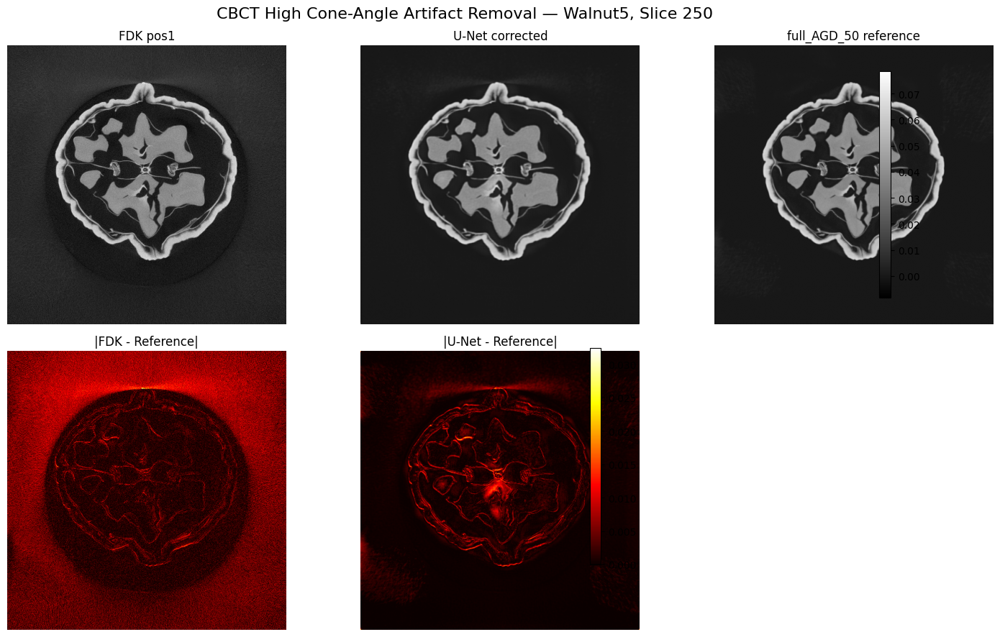

Saved visualization to:
/content/drive/MyDrive/WalnutsOwnReconstructions/walnut5_visual_comparison.png


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import tifffile

# --------------------------------------------------
# Load one sample from unseen Walnut5
# --------------------------------------------------

model.eval()

# Choose a slice from Walnut5
sample_idx = 250

x, y = test_dataset_pos1[sample_idx]

# Add batch dimension and move to GPU
x_input = x.unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(x_input)

# Move everything back to CPU
fdk = x.squeeze(0).numpy()
gt = y.squeeze(0).numpy()
unet = prediction.squeeze(0).squeeze(0).cpu().numpy()

# --------------------------------------------------
# Error maps
# --------------------------------------------------

fdk_error = np.abs(fdk - gt)
unet_error = np.abs(unet - gt)

# --------------------------------------------------
# Use the same intensity scale for all reconstructions
# --------------------------------------------------

vmin = min(fdk.min(), unet.min(), gt.min())
vmax = max(fdk.max(), unet.max(), gt.max())

# Error scale shared between both error maps
error_vmax = max(fdk_error.max(), unet_error.max())

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: reconstructions
im0 = axes[0, 0].imshow(fdk, cmap="gray", vmin=vmin, vmax=vmax)
axes[0, 0].set_title("FDK pos1")
axes[0, 0].axis("off")

im1 = axes[0, 1].imshow(unet, cmap="gray", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("U-Net corrected")
axes[0, 1].axis("off")

im2 = axes[0, 2].imshow(gt, cmap="gray", vmin=vmin, vmax=vmax)
axes[0, 2].set_title("full_AGD_50 reference")
axes[0, 2].axis("off")

# Row 2: absolute error
im3 = axes[1, 0].imshow(fdk_error, cmap="hot", vmin=0, vmax=error_vmax)
axes[1, 0].set_title("|FDK - Reference|")
axes[1, 0].axis("off")

im4 = axes[1, 1].imshow(unet_error, cmap="hot", vmin=0, vmax=error_vmax)
axes[1, 1].set_title("|U-Net - Reference|")
axes[1, 1].axis("off")

axes[1, 2].axis("off")

# Colorbars
fig.colorbar(im0, ax=axes[0, :], fraction=0.02, pad=0.02)
fig.colorbar(im3, ax=axes[1, :2], fraction=0.02, pad=0.02)

fig.suptitle(
    f"CBCT High Cone-Angle Artifact Removal — Walnut5, Slice {sample_idx}",
    fontsize=16
)

plt.tight_layout()

# Save for GitHub
output_path = base / "walnut5_visual_comparison.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved visualization to:")
print(output_path)

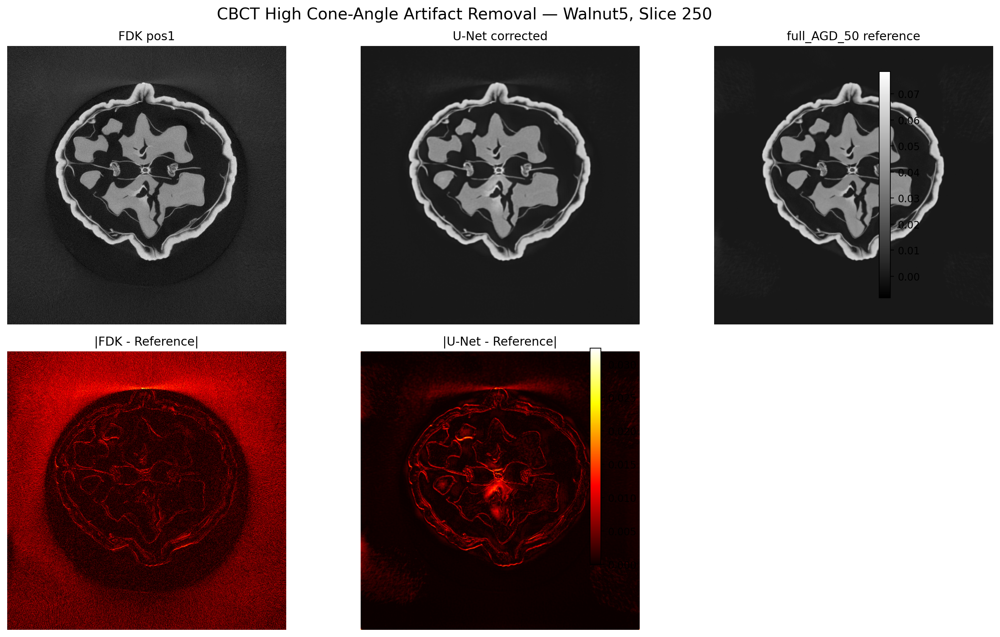

In [ ]:
# check that the image was saved correctly and display it
from IPython.display import display, Image

display(Image(filename=str(base / "walnut5_visual_comparison.png")))

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt

model.eval()

# --------------------------------------------------
# Find the most informative slices in unseen Walnut5
# --------------------------------------------------

slice_errors = []

with torch.no_grad():
    for idx in range(len(test_dataset_pos1)):
        x, y = test_dataset_pos1[idx]

        x_input = x.unsqueeze(0).to(device)

        prediction = model(x_input)

        fdk = x.squeeze(0).numpy()
        gt = y.squeeze(0).numpy()

        # FDK reconstruction error for this slice
        error = np.sqrt(np.mean((fdk - gt) ** 2))

        slice_errors.append(error)

slice_errors = np.array(slice_errors)

# Sort slices by FDK error
best_indices = np.argsort(slice_errors)[::-1]

print("Top 10 Walnut5 slices by FDK RMSE:")
for i in range(10):
    idx = best_indices[i]
    print(f"Slice {idx:03d}: RMSE = {slice_errors[idx]:.6f}")

Top 10 Walnut5 slices by FDK RMSE:
Slice 073: RMSE = 0.009284
Slice 074: RMSE = 0.009255
Slice 072: RMSE = 0.009214
Slice 075: RMSE = 0.009168
Slice 076: RMSE = 0.009022
Slice 071: RMSE = 0.008949
Slice 077: RMSE = 0.008927
Slice 078: RMSE = 0.008762
Slice 079: RMSE = 0.008573
Slice 070: RMSE = 0.008533


FDK shape: (501, 501)
U-Net shape: (501, 501)
GT shape: (501, 501)

Walnut5 slice 73
FDK RMSE:      0.009284
U-Net RMSE:    0.008955
RMSE reduction: 3.54%


/tmp/ipykernel_6541/1119798827.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


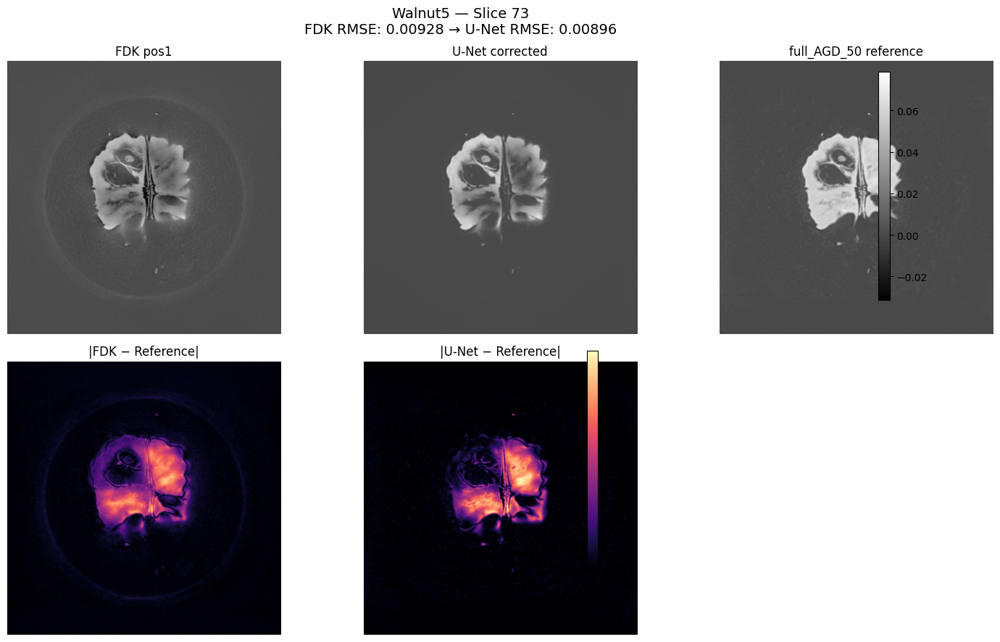


Saved to:
/content/drive/MyDrive/WalnutsOwnReconstructions/walnut5_slice073_qualitative_comparison.png


In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# --------------------------------------------------
# Select informative Walnut5 slice
# --------------------------------------------------
slice_idx = 73

# Load data
x, y = test_dataset_pos1[slice_idx]

# --------------------------------------------------
# Run U-Net
# --------------------------------------------------
model.eval()

with torch.no_grad():
    prediction = model(
        x.unsqueeze(0).to(device)
    ).cpu().squeeze().numpy()   # <-- squeeze ALL singleton dimensions

# Convert input and target to 2D
fdk = x.squeeze().numpy()
gt = y.squeeze().numpy()

print("FDK shape:", fdk.shape)
print("U-Net shape:", prediction.shape)
print("GT shape:", gt.shape)

# --------------------------------------------------
# Compute error maps
# --------------------------------------------------
fdk_error = np.abs(fdk - gt)
unet_error = np.abs(prediction - gt)

# Same intensity scale for all reconstruction images
vmin = min(fdk.min(), prediction.min(), gt.min())
vmax = max(fdk.max(), prediction.max(), gt.max())

# Same error scale for both error maps
error_vmax = max(fdk_error.max(), unet_error.max())

# --------------------------------------------------
# Slice-level metrics
# --------------------------------------------------
fdk_rmse = np.sqrt(np.mean((fdk - gt) ** 2))
unet_rmse = np.sqrt(np.mean((prediction - gt) ** 2))

improvement = (fdk_rmse - unet_rmse) / fdk_rmse * 100

print(f"\nWalnut5 slice {slice_idx}")
print(f"FDK RMSE:      {fdk_rmse:.6f}")
print(f"U-Net RMSE:    {unet_rmse:.6f}")
print(f"RMSE reduction: {improvement:.2f}%")

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row
im0 = axes[0, 0].imshow(
    fdk,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
axes[0, 0].set_title("FDK pos1")

im1 = axes[0, 1].imshow(
    prediction,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
axes[0, 1].set_title("U-Net corrected")

im2 = axes[0, 2].imshow(
    gt,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
axes[0, 2].set_title("full_AGD_50 reference")

# Bottom row
im3 = axes[1, 0].imshow(
    fdk_error,
    cmap="magma",
    vmin=0,
    vmax=error_vmax
)
axes[1, 0].set_title("|FDK − Reference|")

im4 = axes[1, 1].imshow(
    unet_error,
    cmap="magma",
    vmin=0,
    vmax=error_vmax
)
axes[1, 1].set_title("|U-Net − Reference|")

axes[1, 2].axis("off")

# Remove axes
for ax in axes.flat:
    ax.axis("off")

# Colorbars
fig.colorbar(
    im0,
    ax=axes[0, :],
    fraction=0.02,
    pad=0.02
)

fig.colorbar(
    im3,
    ax=axes[1, :2],
    fraction=0.02,
    pad=0.02
)

fig.suptitle(
    f"Walnut5 — Slice {slice_idx}\n"
    f"FDK RMSE: {fdk_rmse:.5f} → "
    f"U-Net RMSE: {unet_rmse:.5f}",
    fontsize=14
)

plt.tight_layout()

# --------------------------------------------------
# Save figure
# --------------------------------------------------
output_path = (
    base / "walnut5_slice073_qualitative_comparison.png"
)

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nSaved to:")
print(output_path)

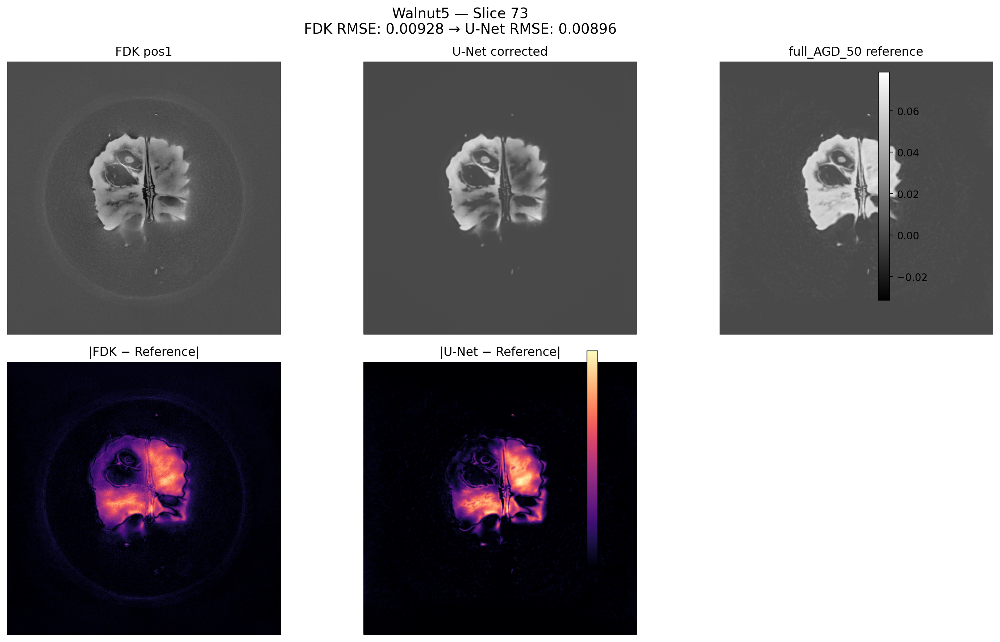

In [ ]:
#check the saved image and display it in the notebook
from IPython.display import display
from PIL import Image

img = Image.open(
    base / "walnut5_slice073_qualitative_comparison.png"
)

display(img)

In [ ]:
# let's check the version of scikit-image installed in the environment
import skimage

print("scikit-image version:", skimage.__version__)

scikit-image version: 0.25.2


In [ ]:
# lets mount again the google drive to make sure we have access to the files after session reset
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# let's check the checkpoint path and verify if it exists
from pathlib import Path

base = Path(
    "/content/drive/MyDrive/WalnutsOwnReconstructions"
)

checkpoint_path = base / "best_unet_pos1_multiwalnut.pth"

print("Base:", base)
print("Checkpoint:", checkpoint_path)
print("Checkpoint exists:", checkpoint_path.exists())

Base: /content/drive/MyDrive/WalnutsOwnReconstructions
Checkpoint: /content/drive/MyDrive/WalnutsOwnReconstructions/best_unet_pos1_multiwalnut.pth
Checkpoint exists: True


In [ ]:
# let's check the contents of the base directory and list all .pth files, which are the saved model checkpoints
print(list(base.glob("*.pth")))

[PosixPath('/content/drive/MyDrive/WalnutsOwnReconstructions/best_unet_pos1_multiwalnut.pth')]


In [ ]:
# lets restore the model to cpu / no GPU mode and load the checkpoint to verify it works
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool1(e1)
        )

        e3 = self.enc3(
            self.pool2(e2)
        )

        b = self.bottleneck(
            self.pool3(e3)
        )

        d3 = self.up3(b)

        d3 = F.interpolate(
            d3,
            size=e3.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = F.interpolate(
            d2,
            size=e2.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = F.interpolate(
            d1,
            size=e1.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        return self.out(d1)


print("U-Net architecture restored.")

U-Net architecture restored.


In [ ]:
# the used device is cpu, since the GPU is not available in this session. We will load the checkpoint to verify it works correctly.
device = torch.device("cpu")

model = UNet().to(device)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint)
model.eval()

print("Device:", device)
print("Best U-Net checkpoint loaded successfully!")

Device: cpu
Best U-Net checkpoint loaded successfully!


In [9]:
# Datasets class
import numpy as np
import tifffile
import torch
from torch.utils.data import Dataset, DataLoader


class MultiWalnutDataset(Dataset):

    def __init__(self, base_dir, walnuts, position="pos1"):

        self.base_dir = Path(base_dir)
        self.walnuts = walnuts
        self.position = position
        self.samples = []

        for walnut in walnuts:

            walnut_dir = self.base_dir / walnut

            inputs = sorted(
                walnut_dir.glob(
                    f"fdk_{position}_*.tiff"
                )
            )

            targets = sorted(
                walnut_dir.glob(
                    "full_AGD_50_*.tiff"
                )
            )

            if len(inputs) != len(targets):
                raise RuntimeError(
                    f"{walnut}: "
                    f"{len(inputs)} inputs vs "
                    f"{len(targets)} targets"
                )

            for input_file, target_file in zip(
                inputs,
                targets
            ):

                self.samples.append({
                    "walnut": walnut,
                    "input": input_file,
                    "target": target_file
                })

        print(
            f"Position {position}: "
            f"{len(self.samples)} samples"
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        x = tifffile.imread(
            sample["input"]
        ).astype(np.float32)

        y = tifffile.imread(
            sample["target"]
        ).astype(np.float32)

        x = torch.from_numpy(x).unsqueeze(0)
        y = torch.from_numpy(y).unsqueeze(0)

        return x, y

In [ ]:
# let's create a test dataset for Walnut5 and check the number of samples
test_walnuts = ["walnut5"]

test_dataset_pos1 = MultiWalnutDataset(
    base,
    test_walnuts,
    position="pos1"
)

test_loader_pos1 = DataLoader(
    test_dataset_pos1,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print("Test samples:", len(test_dataset_pos1))

Position pos1: 501 samples
Test samples: 501


In [11]:
# quick check sanity
x, y = test_dataset_pos1[73]

print("Input shape:", x.shape)
print("Target shape:", y.shape)

print(
    "Input range:",
    x.min().item(),
    "to",
    x.max().item()
)

print(
    "Target range:",
    y.min().item(),
    "to",
    y.max().item()
)

Input shape: torch.Size([1, 501, 501])
Target shape: torch.Size([1, 501, 501])
Input range: -0.03138238936662674 to 0.07406498491764069
Target range: 0.0 to 0.07862875610589981


In [ ]:
# Data analysis and visualization for Walnut5 slice 73, min max vales.
import matplotlib.pyplot as plt
import numpy as np

# Walnut5 slice 73
x, y = test_dataset_pos1[73]

# Add batch dimension
x_input = x.unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(x_input)

# Convert to 2D NumPy arrays
fdk = x.squeeze().numpy()
gt = y.squeeze().numpy()
unet = prediction.squeeze().cpu().numpy()

print("FDK shape:", fdk.shape)
print("U-Net shape:", unet.shape)
print("GT shape:", gt.shape)

print("\nRanges:")
print("FDK :", fdk.min(), "to", fdk.max())
print("U-Net:", unet.min(), "to", unet.max())
print("GT  :", gt.min(), "to", gt.max())

FDK shape: (501, 501)
U-Net shape: (501, 501)
GT shape: (501, 501)

Ranges:
FDK : -0.03138239 to 0.074064985
U-Net: -0.0027340706 to 0.068079375
GT  : 0.0 to 0.078628756


In [ ]:
# Data analysis RMSE, PSNR, SSIM for Walnut5 slice 73
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity
)

fdk_rmse_73 = np.sqrt(
    mean_squared_error(gt, fdk)
)

unet_rmse_73 = np.sqrt(
    mean_squared_error(gt, unet)
)

data_range = gt.max() - gt.min()

fdk_psnr_73 = peak_signal_noise_ratio(
    gt,
    fdk,
    data_range=data_range
)

unet_psnr_73 = peak_signal_noise_ratio(
    gt,
    unet,
    data_range=data_range
)

fdk_ssim_73 = structural_similarity(
    gt,
    fdk,
    data_range=data_range
)

unet_ssim_73 = structural_similarity(
    gt,
    unet,
    data_range=data_range
)

print("Walnut5 — Slice 73")
print("=" * 45)

print(
    f"FDK  : RMSE={fdk_rmse_73:.6f}, "
    f"PSNR={fdk_psnr_73:.3f} dB, "
    f"SSIM={fdk_ssim_73:.4f}"
)

print(
    f"U-Net: RMSE={unet_rmse_73:.6f}, "
    f"PSNR={unet_psnr_73:.3f} dB, "
    f"SSIM={unet_ssim_73:.4f}"
)

rmse_reduction_73 = (
    (fdk_rmse_73 - unet_rmse_73)
    / fdk_rmse_73
    * 100
)

print(
    f"\nRMSE reduction: "
    f"{rmse_reduction_73:.2f}%"
)

Walnut5 — Slice 73
FDK  : RMSE=0.009284, PSNR=18.557 dB, SSIM=0.4628
U-Net: RMSE=0.008955, PSNR=18.870 dB, SSIM=0.7272

RMSE reduction: 3.54%


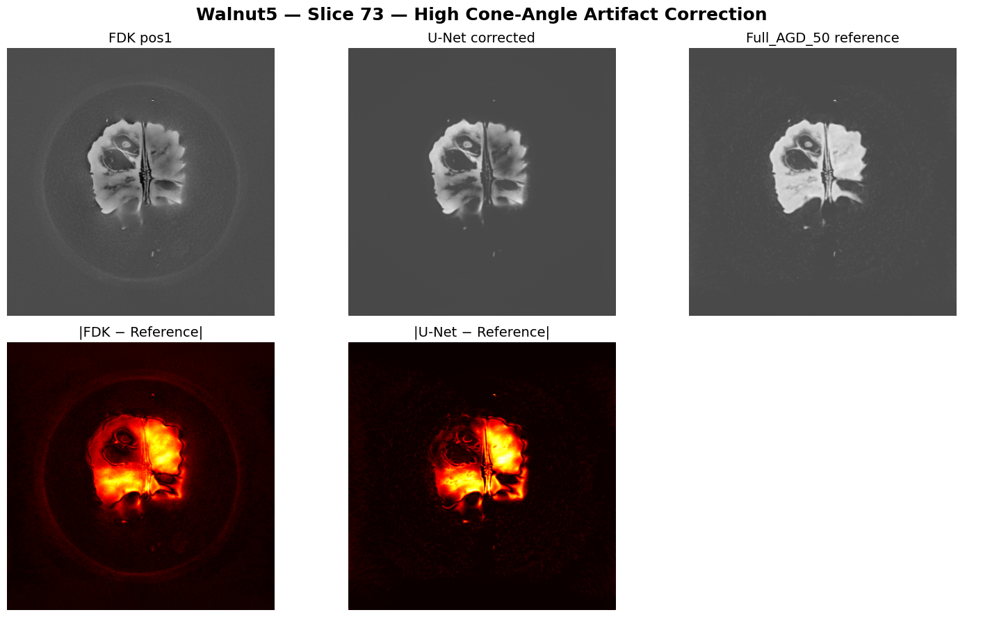

Saved figure:
/content/drive/MyDrive/WalnutsOwnReconstructions/walnut5_slice073_qualitative_comparison.png


In [ ]:
# visualization of Walnut5 slice 73 reconstructions and error maps
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

# --------------------------------------------------
# Reconstruction intensity range
# --------------------------------------------------

vmin = min(
    fdk.min(),
    unet.min(),
    gt.min()
)

vmax = max(
    fdk.max(),
    unet.max(),
    gt.max()
)

# --------------------------------------------------
# Error maps
# --------------------------------------------------

fdk_error = np.abs(fdk - gt)
unet_error = np.abs(unet - gt)

error_vmax = max(
    fdk_error.max(),
    unet_error.max()
)

# --------------------------------------------------
# Top row: reconstructions
# --------------------------------------------------

axes[0, 0].imshow(
    fdk,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

axes[0, 0].set_title(
    "FDK pos1",
    fontsize=14
)

axes[0, 1].imshow(
    unet,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

axes[0, 1].set_title(
    "U-Net corrected",
    fontsize=14
)

axes[0, 2].imshow(
    gt,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

axes[0, 2].set_title(
    "Full_AGD_50 reference",
    fontsize=14
)

# --------------------------------------------------
# Bottom row: error maps
# --------------------------------------------------

axes[1, 0].imshow(
    fdk_error,
    cmap="hot",
    vmin=0,
    vmax=error_vmax
)

axes[1, 0].set_title(
    "|FDK − Reference|",
    fontsize=14
)

axes[1, 1].imshow(
    unet_error,
    cmap="hot",
    vmin=0,
    vmax=error_vmax
)

axes[1, 1].set_title(
    "|U-Net − Reference|",
    fontsize=14
)

axes[1, 2].axis("off")

# --------------------------------------------------
# Formatting
# --------------------------------------------------

for ax in axes.flat:
    ax.axis("off")

fig.suptitle(
    "Walnut5 — Slice 73 — High Cone-Angle Artifact Correction",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

# Save to Drive
figure_path = (
    base /
    "walnut5_slice073_qualitative_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:")
print(figure_path)

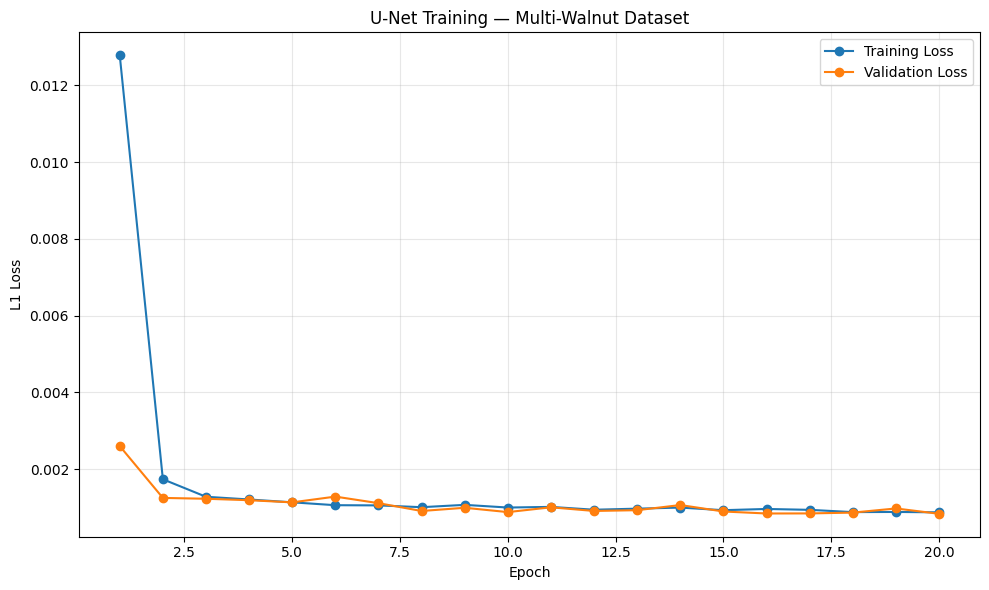

Saved:
/content/drive/MyDrive/WalnutsOwnReconstructions/training_curve_pos1_multiwalnut.png

Best validation loss: 0.000833
Best epoch: 20


In [ ]:
# saved the training and validation loss curves for the U-Net model trained on the multi-walnut dataset
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 21)

train_loss = [
    0.012784,
    0.001733,
    0.001277,
    0.001206,
    0.001132,
    0.001057,
    0.001052,
    0.001005,
    0.001066,
    0.000996,
    0.001013,
    0.000939,
    0.000967,
    0.000995,
    0.000927,
    0.000959,
    0.000936,
    0.000877,
    0.000881,
    0.000871
]

val_loss = [
    0.002598,
    0.001247,
    0.001225,
    0.001187,
    0.001131,
    0.001281,
    0.001110,
    0.000906,
    0.000990,
    0.000877,
    0.001002,
    0.000907,
    0.000927,
    0.001061,
    0.000893,
    0.000841,
    0.000843,
    0.000864,
    0.000972,
    0.000833
]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title(
    "U-Net Training — Multi-Walnut Dataset"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

training_curve_path = (
    base / "training_curve_pos1_multiwalnut.png"
)

plt.savefig(
    training_curve_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(training_curve_path)

best_epoch = np.argmin(val_loss) + 1

print(
    f"\nBest validation loss: "
    f"{val_loss[best_epoch-1]:.6f}"
)

print(
    f"Best epoch: {best_epoch}"
)

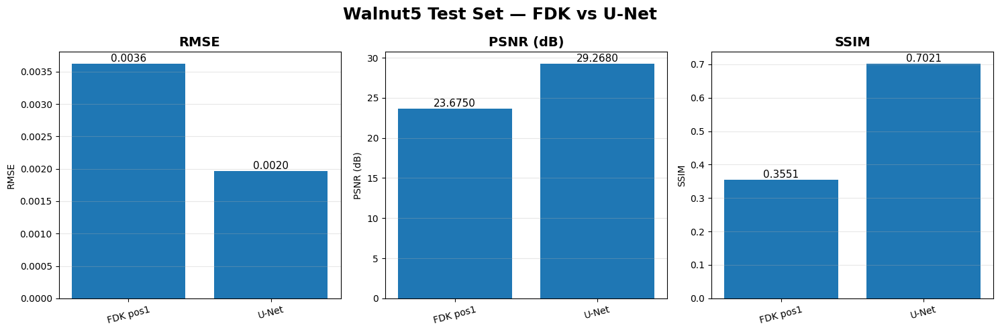

Saved:
/content/drive/MyDrive/WalnutsOwnReconstructions/walnut5_fdk_vs_unet_metrics.png


In [16]:
# create the metrics figure
import matplotlib.pyplot as plt
import numpy as np

# Mean per-slice metrics across all 501 Walnut5 slices
metrics = {
    "RMSE": {
        "FDK pos1": 0.003623,
        "U-Net": 0.001969
    },
    "PSNR (dB)": {
        "FDK pos1": 23.675,
        "U-Net": 29.268
    },
    "SSIM": {
        "FDK pos1": 0.3551,
        "U-Net": 0.7021
    }
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

for ax, (metric, values) in zip(
    axes,
    metrics.items()
):

    labels = list(values.keys())
    numbers = list(values.values())

    bars = ax.bar(
        labels,
        numbers
    )

    ax.set_title(
        metric,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_ylabel(metric)

    ax.grid(
        axis="y",
        alpha=0.3
    )

    # Add values above bars
    for bar, value in zip(bars, numbers):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.tick_params(
        axis="x",
        rotation=15
    )

fig.suptitle(
    "Walnut5 Test Set — FDK vs U-Net",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

metrics_figure_path = (
    base /
    "walnut5_fdk_vs_unet_metrics.png"
)

plt.savefig(
    metrics_figure_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(metrics_figure_path)

In [17]:
# add RMSE reduction percentage to the metrics figure
rmse_reduction = (
    (0.003623 - 0.001969)
    / 0.003623
    * 100
)

print(f"RMSE reduction: {rmse_reduction:.2f}%")

RMSE reduction: 45.65%


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/WalnutsOwnReconstructions")

print("Project directory:")
print(BASE_DIR)

print("\nContents:")
for p in sorted(BASE_DIR.iterdir()):
    print(p.name)

Project directory:
/content/drive/MyDrive/WalnutsOwnReconstructions

Contents:
best_unet_pos1_multiwalnut.pth
projections
sks_prototype
training_curve_pos1_multiwalnut.png
walnut1
walnut5_fdk_vs_unet_metrics.png
walnut5_slice073_qualitative_comparison.png
walnut5_visual_comparison.png


In [3]:
from pathlib import Path

WALNUT_DIR = Path("/content/drive/MyDrive/WalnutsOwnReconstructions/walnut1")

print("Walnut1 contents:\n")

for p in sorted(WALNUT_DIR.iterdir()):
    print(p.name)

Walnut1 contents:

best_unet_pos1.pth
fdk_pos1_000000.tiff
fdk_pos1_000001.tiff
fdk_pos1_000002.tiff
fdk_pos1_000003.tiff
fdk_pos1_000004.tiff
fdk_pos1_000005.tiff
fdk_pos1_000006.tiff
fdk_pos1_000007.tiff
fdk_pos1_000008.tiff
fdk_pos1_000009.tiff
fdk_pos1_000010.tiff
fdk_pos1_000011.tiff
fdk_pos1_000012.tiff
fdk_pos1_000013.tiff
fdk_pos1_000014.tiff
fdk_pos1_000015.tiff
fdk_pos1_000016.tiff
fdk_pos1_000017.tiff
fdk_pos1_000018.tiff
fdk_pos1_000019.tiff
fdk_pos1_000020.tiff
fdk_pos1_000021.tiff
fdk_pos1_000022.tiff
fdk_pos1_000023.tiff
fdk_pos1_000024.tiff
fdk_pos1_000025.tiff
fdk_pos1_000026.tiff
fdk_pos1_000027.tiff
fdk_pos1_000028.tiff
fdk_pos1_000029.tiff
fdk_pos1_000030.tiff
fdk_pos1_000031.tiff
fdk_pos1_000032.tiff
fdk_pos1_000033.tiff
fdk_pos1_000034.tiff
fdk_pos1_000035.tiff
fdk_pos1_000036.tiff
fdk_pos1_000037.tiff
fdk_pos1_000038.tiff
fdk_pos1_000039.tiff
fdk_pos1_000040.tiff
fdk_pos1_000041.tiff
fdk_pos1_000042.tiff
fdk_pos1_000043.tiff
fdk_pos1_000044.tiff
fdk_pos1_000045.t

In [4]:
import tifffile
import numpy as np

files = sorted(WALNUT_DIR.glob("*.tiff"))

print(f"\nNumber of TIFF files: {len(files)}\n")

for f in files[:10]:
    img = tifffile.imread(f)
    print(f"{f.name:40s} shape={img.shape}, dtype={img.dtype}, "
          f"min={img.min():.6f}, max={img.max():.6f}")


Number of TIFF files: 2004

fdk_pos1_000000.tiff                     shape=(501, 501), dtype=float32, min=-0.001590, max=0.010554
fdk_pos1_000001.tiff                     shape=(501, 501), dtype=float32, min=-0.001768, max=0.010599
fdk_pos1_000002.tiff                     shape=(501, 501), dtype=float32, min=-0.002071, max=0.010744
fdk_pos1_000003.tiff                     shape=(501, 501), dtype=float32, min=-0.001784, max=0.012204
fdk_pos1_000004.tiff                     shape=(501, 501), dtype=float32, min=-0.002055, max=0.011214
fdk_pos1_000005.tiff                     shape=(501, 501), dtype=float32, min=-0.001325, max=0.012156
fdk_pos1_000006.tiff                     shape=(501, 501), dtype=float32, min=-0.001725, max=0.011886
fdk_pos1_000007.tiff                     shape=(501, 501), dtype=float32, min=-0.002971, max=0.011992
fdk_pos1_000008.tiff                     shape=(501, 501), dtype=float32, min=-0.001698, max=0.014436
fdk_pos1_000009.tiff                     shape=(501, 

In [9]:
# lets load the model and construct a 3D volume from the 2D slices of Walnut1 using the trained U-Net model
import numpy as np
import tifffile
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

BASE_DIR = Path("/content/drive/MyDrive/WalnutsOwnReconstructions")
WALNUT_DIR = BASE_DIR / "walnut1"
MODEL_PATH = BASE_DIR / "best_unet_pos1_multiwalnut.pth"

print("Walnut directory:", WALNUT_DIR)
print("Model:", MODEL_PATH)

# --------------------------------------------------
# U-Net definition
# --------------------------------------------------

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool1(e1)
        )

        e3 = self.enc3(
            self.pool2(e2)
        )

        b = self.bottleneck(
            self.pool3(e3)
        )

        d3 = self.up3(b)
        d3 = F.interpolate(
            d3,
            size=e3.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = F.interpolate(
            d2,
            size=e2.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = F.interpolate(
            d1,
            size=e1.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


# --------------------------------------------------
# Load model
# --------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = UNet().to(device)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

# Handle either a raw state_dict or a checkpoint dictionary
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("U-Net loaded successfully.")


# --------------------------------------------------
# Find and numerically sort slices
# --------------------------------------------------

def slice_number(path):
    return int(path.stem.split("_")[-1])

# lets fo it for the whole positions 
fdk_files = sorted(
    WALNUT_DIR.glob("fdk_pos1_*.tiff"),
    key=slice_number
)

ref_files = sorted(
    WALNUT_DIR.glob("full_AGD_50_*.tiff"),
    key=slice_number
)

print("\nFDK slices:", len(fdk_files))
print("Reference slices:", len(ref_files))

assert len(fdk_files) == len(ref_files)

# --------------------------------------------------
# Read volumes
# --------------------------------------------------

fdk_volume = np.stack([
    tifffile.imread(f).astype(np.float32)
    for f in fdk_files
])

reference_volume = np.stack([
    tifffile.imread(f).astype(np.float32)
    for f in ref_files
])

print("\nVolume shape:")
print("FDK:       ", fdk_volume.shape)
print("Reference: ", reference_volume.shape)

print("\nFDK range:")
print(fdk_volume.min(), fdk_volume.max())

print("\nReference range:")
print(reference_volume.min(), reference_volume.max())

Walnut directory: /content/drive/MyDrive/WalnutsOwnReconstructions/walnut1
Model: /content/drive/MyDrive/WalnutsOwnReconstructions/best_unet_pos1_multiwalnut.pth
Using device: cuda
U-Net loaded successfully.

FDK slices: 501
Reference slices: 501

Volume shape:
FDK:        (501, 501, 501)
Reference:  (501, 501, 501)

FDK range:
-0.04270558 0.2284293

Reference range:
0.0 0.16388609


In [6]:
# --------------------------------------------------
# U-Net inference on all slices
# --------------------------------------------------

predicted_slices = []

with torch.no_grad():

    for i, fdk_file in enumerate(fdk_files):

        img = tifffile.imread(
            fdk_file
        ).astype(np.float32)

        x = torch.from_numpy(img)
        x = x.unsqueeze(0).unsqueeze(0)
        x = x.to(device)

        prediction = model(x)

        prediction = prediction.squeeze().cpu().numpy()

        predicted_slices.append(prediction)

        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(fdk_files)} slices")

unet_volume = np.stack(predicted_slices)

print("\nU-Net volume shape:", unet_volume.shape)

print(
    "U-Net range:",
    unet_volume.min(),
    unet_volume.max()
)

Processed 50/501 slices
Processed 100/501 slices
Processed 150/501 slices
Processed 200/501 slices
Processed 250/501 slices
Processed 300/501 slices
Processed 350/501 slices
Processed 400/501 slices
Processed 450/501 slices
Processed 500/501 slices

U-Net volume shape: (501, 501, 501)
U-Net range: -0.0063431785 0.0796534


Volume center:
x = 250
y = 250

Common intensity window:
vmin = 0.0
vmax = 0.059110645

Error display limit:
± 0.017780917


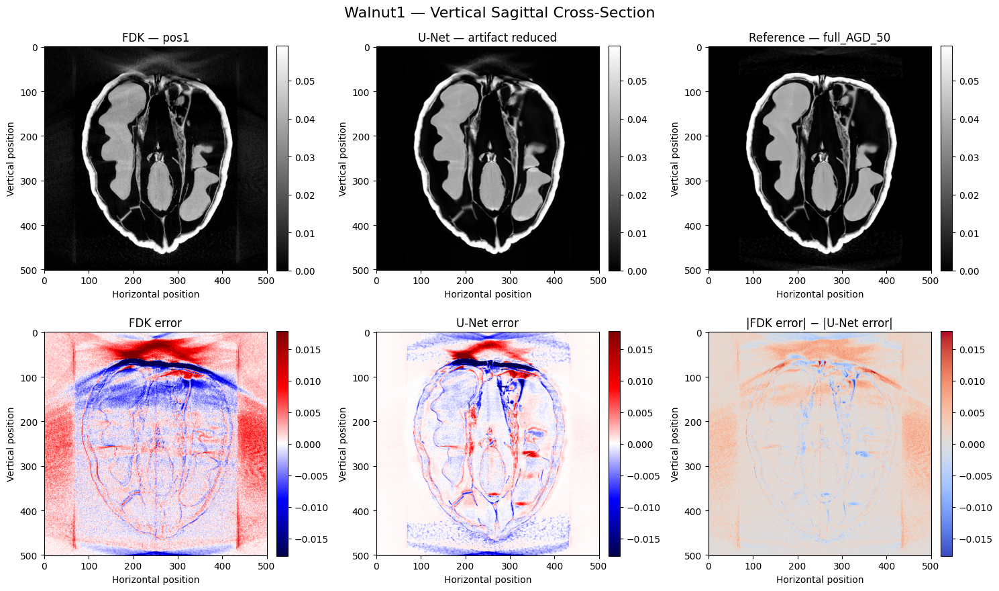

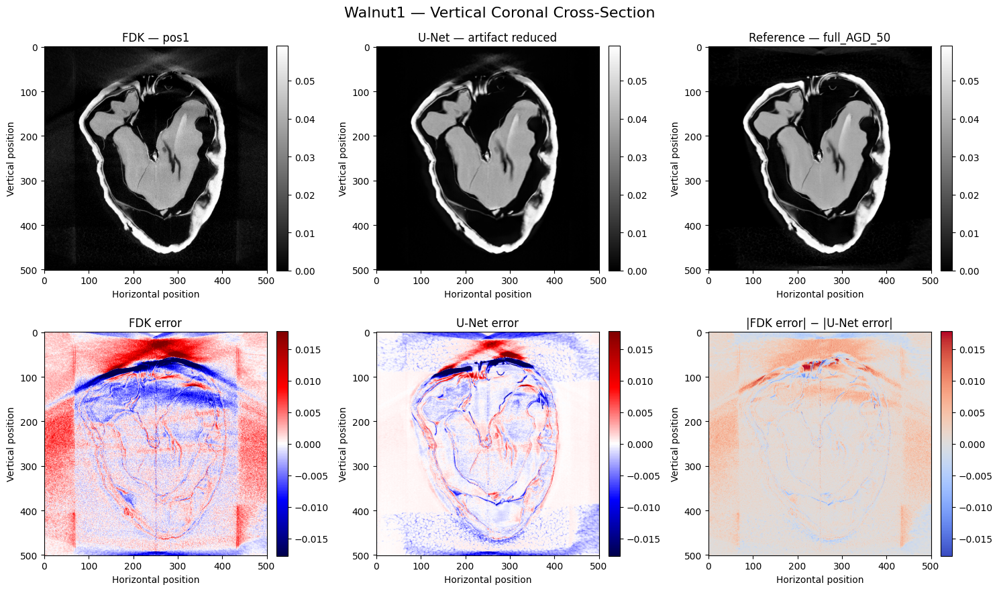

In [7]:
# ============================================================
# VERTICAL CROSS-SECTION COMPARISON
# FDK vs U-Net vs Reference
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Choose the vertical planes
# ------------------------------------------------------------

# Center of the reconstructed volume
center_x = fdk_volume.shape[2] // 2
center_y = fdk_volume.shape[1] // 2

print("Volume center:")
print("x =", center_x)
print("y =", center_y)


# ------------------------------------------------------------
# Extract vertical sections
# ------------------------------------------------------------

# Volume convention:
# volume[z, y, x]

# Sagittal:
# fix x -> z/y plane
fdk_sagittal = fdk_volume[:, :, center_x]
unet_sagittal = unet_volume[:, :, center_x]
ref_sagittal = reference_volume[:, :, center_x]

# Coronal:
# fix y -> z/x plane
fdk_coronal = fdk_volume[:, center_y, :]
unet_coronal = unet_volume[:, center_y, :]
ref_coronal = reference_volume[:, center_y, :]


# ------------------------------------------------------------
# Error maps
# ------------------------------------------------------------

fdk_sag_error = fdk_sagittal - ref_sagittal
unet_sag_error = unet_sagittal - ref_sagittal

fdk_cor_error = fdk_coronal - ref_coronal
unet_cor_error = unet_coronal - ref_coronal


# ------------------------------------------------------------
# Common intensity window
# ------------------------------------------------------------

# Use the reference volume to define a robust CT display window.
vmin = np.percentile(reference_volume, 1)
vmax = np.percentile(reference_volume, 99)

print("\nCommon intensity window:")
print("vmin =", vmin)
print("vmax =", vmax)


# ------------------------------------------------------------
# Common error window
# ------------------------------------------------------------

all_errors = np.concatenate([
    np.abs(fdk_sag_error).ravel(),
    np.abs(unet_sag_error).ravel(),
    np.abs(fdk_cor_error).ravel(),
    np.abs(unet_cor_error).ravel()
])

error_limit = np.percentile(all_errors, 99)

print("\nError display limit:")
print("±", error_limit)


# ============================================================
# FIGURE 1 — SAGITTAL
# ============================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

images = [
    fdk_sagittal,
    unet_sagittal,
    ref_sagittal,
    fdk_sag_error,
    unet_sag_error,
    np.abs(fdk_sag_error) - np.abs(unet_sag_error)
]

titles = [
    "FDK — pos1",
    "U-Net — artifact reduced",
    "Reference — full_AGD_50",
    "FDK error",
    "U-Net error",
    "|FDK error| − |U-Net error|"
]

for ax, img, title in zip(axes.ravel(), images, titles):

    if "error" in title.lower():

        im = ax.imshow(
            img,
            cmap="seismic" if "−" not in title else "coolwarm",
            vmin=-error_limit if "−" in title else -error_limit,
            vmax=error_limit
        )

    else:

        im = ax.imshow(
            img,
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )

    ax.set_title(title)
    ax.set_xlabel("Horizontal position")
    ax.set_ylabel("Vertical position")
    ax.set_aspect("equal")

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

plt.suptitle(
    "Walnut1 — Vertical Sagittal Cross-Section",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — CORONAL
# ============================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

images = [
    fdk_coronal,
    unet_coronal,
    ref_coronal,
    fdk_cor_error,
    unet_cor_error,
    np.abs(fdk_cor_error) - np.abs(unet_cor_error)
]

titles = [
    "FDK — pos1",
    "U-Net — artifact reduced",
    "Reference — full_AGD_50",
    "FDK error",
    "U-Net error",
    "|FDK error| − |U-Net error|"
]

for ax, img, title in zip(axes.ravel(), images, titles):

    if "error" in title.lower():

        im = ax.imshow(
            img,
            cmap="seismic" if "−" not in title else "coolwarm",
            vmin=-error_limit,
            vmax=error_limit
        )

    else:

        im = ax.imshow(
            img,
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )

    ax.set_title(title)
    ax.set_xlabel("Horizontal position")
    ax.set_ylabel("Vertical position")
    ax.set_aspect("equal")

    plt.colorbar(
        im,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

plt.suptitle(
    "Walnut1 — Vertical Coronal Cross-Section",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Conclusion — Multi-Walnut U-Net Model

The multi-walnut U-Net model successfully learned to reduce high cone-angle artifacts in single-orbit `fdk_pos1` CBCT reconstructions.

The model was trained on **Walnut1–3**, validated on **Walnut4**, and evaluated on the completely unseen **Walnut5** test set. The quantitative results, averaged over the **501 test slices**, show a clear improvement compared with the original FDK reconstruction:

| Metric | FDK pos1 | U-Net |
|---|---:|---:|
| RMSE | 0.003623 | **0.001969** |
| PSNR | 23.675 dB | **29.268 dB** |
| SSIM | 0.3551 | **0.7021** |

The U-Net achieved a **45.67% reduction in mean per-slice RMSE**, together with an increase of approximately **5.59 dB in PSNR** and **0.347 in SSIM**.

These results indicate that the model can learn a mapping from the artifact-containing single-orbit FDK reconstruction toward the higher-quality `full_AGD_50` reference, while maintaining performance on an unseen walnut.

The qualitative results and error maps also show a reduction in reconstruction errors compared with the original FDK input.

Overall, this experiment provides a strong proof-of-concept for **deep-learning-based cone-angle artifact reduction in CBCT** and provides a basis for the next steps: testing `pos2` and `pos3`, exploring a multi-position input model, and exporting the trained network for C++ inference.